In [1]:
import torch
import torchvision
import os
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def create_model(weights_name, num_classes):
    """
    Cria a arquitetura do modelo Faster R-CNN com base no nome dos pesos
    e no número de classes.
    """
    try:
        weights_enum = getattr(torchvision.models.detection, weights_name)
        weights = weights_enum.COCO_V1 
    except AttributeError:
        print(f"Aviso: Não foi possível encontrar os pesos '{weights_name}'.")
        print("Usando 'None' (treino do zero).")
        weights = None

    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
    
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    
    return model

def load_model_eval(device, model, pretrained_model_path):
    """
    Carrega os pesos de um modelo salvo, o move para o dispositivo
    e o coloca em modo de avaliação (.eval()).
    """
    # Verifica se o caminho existe
    if not os.path.exists(pretrained_model_path):
        print(f"Erro: Caminho do modelo não encontrado: {pretrained_model_path}")
        return None
        
    # Carrega os pesos (state_dict) no dispositivo correto
    model.load_state_dict(torch.load(pretrained_model_path, map_location=device))
    model.to(device)
    model.eval() 
    
    print(f"\nModelo carregado de {pretrained_model_path}")
    print(f"Modelo movido para '{device}' e em modo de avaliação (.eval()).")
    
    return model

In [7]:
# 1. Definições principais
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 2  # Parâmetros do modelo (os mesmos usados no treino)
weights_str = 'FasterRCNN_ResNet50_FPN_Weights' # Nome da Enum base

# 2. Defina o caminho para o seu modelo
models_path = os.path.join(
            base_dir,
            'data',
            'inputs',
            'ia_models',
            'FRCNN Resnet50',
            #'best_faster_rcnn_model_20250604_111351.pth'
           'best_faster_rcnn_model_20250911_075817.pth'
        )
print(f"Usando dispositivo: {device}")
print(f"Tentando carregar modelo de: {models_path}")

# 3. Criar a arquitetura base
# (É necessário criar a "casca" do modelo antes de carregar os pesos)
print("\n1. Criando arquitetura do modelo...")
model = create_model(weights_str, num_classes)

# 4. Carregar seus pesos salvos na arquitetura
print("2. Carregando pesos salvos...")
model = load_model_eval(device, model, models_path)

# 5. Imprimir a arquitetura do modelo (se ele foi carregado)
if model:
    print("\n--- Arquitetura e Configuração do Modelo Carregado ---")
    print(model)
    print("------------------------------------------------------")
else:
    print("\nFalha ao carregar o modelo. Verifique o caminho e as definições.")

Usando dispositivo: cuda
Tentando carregar modelo de: d:\Arquivos\ProjetosPython\PICOS\data\inputs\ia_models\FRCNN Resnet50\best_faster_rcnn_model_20250911_075817.pth

1. Criando arquitetura do modelo...
2. Carregando pesos salvos...


C:\Users\Gabriel-PC\AppData\Local\Temp\ipykernel_12776\2458008786.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pretrained_model_path


Modelo carregado de d:\Arquivos\ProjetosPython\PICOS\data\inputs\ia_models\FRCNN Resnet50\best_faster_rcnn_model_20250911_075817.pth
Modelo movido para 'cuda' e em modo de avaliação (.eval()).

--- Arquitetura e Configuração do Modelo Carregado ---
FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3,

In [32]:
from collections import defaultdict

def format_num(n):
    """Formata um número grande com pontos para facilitar a leitura."""
    return f'{n:,}'.replace(',', '.')

def print_parameter_summary(model):
    """
    Imprime um resumo do número de parâmetros em cada módulo principal do modelo.
    """
    print("\n--- Resumo dos Parâmetros (Pesos) por Etapa ---")
    print("Isto conta TODOS os parâmetros (treináveis ou não) que estão no modelo carregado.\n")

    # Dicionários para guardar as contagens
    param_counts = defaultdict(int)
    top_level_counts = defaultdict(int)
    total_params = 0

    # Usamos model.state_dict() para pegar TUDO o que foi carregado do arquivo .pth
    # (inclui pesos, biases, médias de BatchNorm, etc.)
    state_dict = model.state_dict()

    for name, param in state_dict.items():
        num_params = param.numel() # .numel() retorna o número total de elementos
        total_params += num_params
        
        parts = name.split('.')
        
        # 1. Contagem de Nível Superior (ex: 'backbone', 'rpn', 'roi_heads')
        top_key = parts[0]
        top_level_counts[top_key] += num_params
        
        # 2. Contagem de Sub-módulo (ex: 'backbone.body', 'backbone.fpn')
        if len(parts) > 1:
            sub_key = f"{parts[0]}.{parts[1]}"
            param_counts[sub_key] += num_params
        else:
            param_counts[name] += num_params # Caso raro

    print(f"Total de Parâmetros no Modelo: {format_num(total_params)}\n")
    
    print("Parâmetros por Módulo Principal:")
    # Ordena pela contagem (do maior para o menor)
    sorted_top = sorted(top_level_counts.items(), key=lambda item: item[1], reverse=True)
    
    for key, count in sorted_top:
        percent = (count / total_params) * 100
        print(f"  - {key:<12}: {format_num(count):>12} parâmetros ({percent:.1f}%)")
        
    print("\nParâmetros por Sub-módulo (Detalhado):")
    # Ordena pelo nome do módulo
    sorted_sub = sorted(param_counts.items())
    for key, count in sorted_sub:
        print(f"  - {key:<25}: {format_num(count):>12} parâmetros")
    
    print("-------------------------------------------------")

In [34]:
# ... (seu código de carregar o modelo) ...

# 5. Imprimir a arquitetura do modelo (se ele foi carregado)
if model:
    print("\n--- Arquitetura e Configuração do Modelo Carregado ---")
    print(model)
    print("------------------------------------------------------")
    
    # ADICIONE A CHAMADA DA FUNÇÃO AQUI
    print_parameter_summary(model)

else:
print("\nFalha ao carregar o modelo. Verifique o caminho e as definições.")


--- Arquitetura e Configuração do Modelo Carregado ---
FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3):

backbone (65,0%): Esta é a ResNet-50 + FPN. É o "olho" do seu modelo. A tarefa dele é processar os pixels brutos da imagem e transformá-los em mapas de características complexos. É de longe a parte mais pesada e cara, pois "aprender a ver" é a tarefa mais difícil.

roi_heads (33,6%): Este é o "cérebro" do seu modelo. Ele pega as características do backbone e as propostas do rpn e toma a decisão final: "Que classe é essa?" e "Onde exatamente está a caixa?".

rpn (1,4%): Esta é a parte mais "leve". É um "assistente" rápido que apenas sugere áreas de interesse. Ele não classifica, apenas diz "Ei, olhe aqui! Isso parece um objeto".

O Poder do Transfer Learning na Prática
O que esses números realmente lhe dizem é a essência do transfer learning:

Você carregou 41.405.401 parâmetros. Desses, você descartou os pesos do box_predictor original e inseriu o seu, que tem apenas 10.250 parâmetros (0,02% do modelo total).

Você congelou (ou treinou com uma taxa de aprendizado muito baixa) os 41,39 milhões de parâmetros que sabem "ver" e "entender" o mundo, e concentrou o treinamento do seu modelo em ajustar apenas esses 10.250 parâmetros (e talvez alguns outros) para se especializarem em encontrar as suas classes.

Você está basicamente usando uma "mente" de 41 milhões de parâmetros, mas focando o "treinamento" apenas na pequena parte que toma a decisão final.

In [16]:
from PIL import Image
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import numpy as np

def show_transformed_image(tensor_batch, 
                           mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225]):
    """
    Desnormaliza um tensor de imagem (do batch) e o exibe usando Matplotlib.
    """
    if not isinstance(tensor_batch, torch.Tensor):
        print("Erro: A entrada não é um tensor.")
        return

    # Pega a primeira imagem do batch (índice 0)
    tensor = tensor_batch.squeeze(0).cpu().detach()
    
    # Prepara os tensores de média e desvio padrão
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    
    # Desnormaliza: (tensor * std) + mean
    denormalized_tensor = tensor * std + mean
    
    # Garante que os valores estão no range [0, 1]
    denormalized_tensor = torch.clamp(denormalized_tensor, 0, 1)
    
    # Converte para NumPy e muda a ordem dos eixos: (C, H, W) -> (H, W, C)
    numpy_image = denormalized_tensor.permute(1, 2, 0).numpy()
    
    # Exibe a imagem
    plt.figure(figsize=(10, 10))
    plt.imshow(numpy_image)
    plt.title(f"Imagem Pós-Transform (Desnormalizada) - Shape: {numpy_image.shape}")
    plt.axis('off')
    plt.show()


--- Teste de Transformação Manual ---
Imagem de teste carregada: D:\Arquivos\ProjetosPython\PICOS\data\inputs\train_images\COCO_20250908\train\SM_14__20250827_121430_jpg.rf.37225ec333273f54e447345dc7b8559f.jpg
Shape do tensor original (C, H, W): torch.Size([3, 640, 640])

--- Resultado da Transformação ---
Shape do tensor transformado (Batch, C, H, W): torch.Size([1, 3, 800, 800])
Dispositivo do tensor: cuda:0
Valor Mínimo (normalizado): -2.1179
Valor Máximo (normalizado): 2.6400

Gerando visualização da imagem transformada (desnormalizada)...


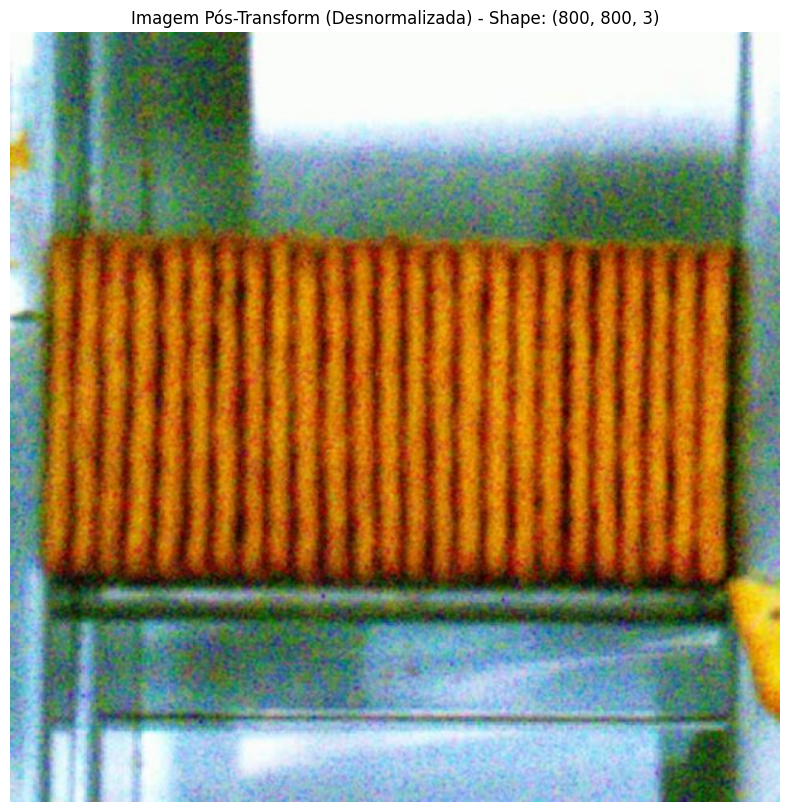

In [17]:
if model:
    print("\n--- Teste de Transformação Manual ---")
    
    TEST_IMAGE_PATH = r'D:\Arquivos\ProjetosPython\PICOS\data\inputs\train_images\COCO_20250908\train\SM_14__20250827_121430_jpg.rf.37225ec333273f54e447345dc7b8559f.jpg'
    
    try:
        # 2. Carregar a imagem com PIL e converter para Tensor
        pil_image = Image.open(TEST_IMAGE_PATH).convert('RGB')
        # sucesso, frame_left = cv2.imencode('.jpg', frame_left)
        # frame_left = cv2.imdecode(frame_left, cv2.IMREAD_COLOR)
        
        # Converte a imagem PIL (H, W, C) para Tensor (C, H, W)
        # e normaliza os pixels para o intervalo [0.0, 1.0]
        image_tensor = F.to_tensor(pil_image)
        
        print(f"Imagem de teste carregada: {TEST_IMAGE_PATH}")
        print(f"Shape do tensor original (C, H, W): {image_tensor.shape}")
        
        # 3. Colocar o modelo em modo de avaliação
        model.eval()
        
        # 4. Executar o 'model.transform'
        with torch.no_grad():
            images_list = [image_tensor.to(device)]
            targets = None
            
            image_list_obj, _ = model.transform(images_list, targets)

        # 5. Analisar a saída
        transformed_tensor_batch = image_list_obj.tensors
        
        print(f"\n--- Resultado da Transformação ---")
        print(f"Shape do tensor transformado (Batch, C, H, W): {transformed_tensor_batch.shape}")
        print(f"Dispositivo do tensor: {transformed_tensor_batch.device}")
        
        # O tensor agora está normalizado (valores negativos e positivos)
        print(f"Valor Mínimo (normalizado): {transformed_tensor_batch.min():.4f}")
        print(f"Valor Máximo (normalizado): {transformed_tensor_batch.max():.4f}")
        
        # 6. Visualizar a imagem (desnormalizada)
        print("\nGerando visualização da imagem transformada (desnormalizada)...")
        show_transformed_image(transformed_tensor_batch)

    except FileNotFoundError:
        print(f"\nERRO: Imagem de teste não encontrada em:")
        print(f"{TEST_IMAGE_PATH}")
        print("Por favor, atualize a variável 'TEST_IMAGE_PATH'.")
    except Exception as e:
        print(f"\nOcorreu um erro ao processar a imagem: {e}")

else:
    print("\nModelo não foi carregado, impossível testar o transform.")

In [18]:
def show_feature_map(tensor_batch, title="Feature Map"):
    """
    Visualiza a média de um mapa de características (batch) 
    de shape [B, C, H, W] usando matplotlib.
    """
    if not isinstance(tensor_batch, torch.Tensor):
        print("Erro: A entrada não é um tensor.")
        return

    # Pega o primeiro (e único) item do batch (índice 0)
    # e remove do dispositivo da GPU (cpu()) e do cálculo de gradiente (detach())
    tensor = tensor_batch[0, :, :, :].cpu().detach()
    
    # Calcula a média através da dimensão dos canais (dim=0)
    mean_feature_map = tensor.mean(dim=0)
    
    # Exibe o mapa de calor
    plt.figure(figsize=(8, 8))
    # Usamos 'viridis' ou 'gray' para mapas de características
    plt.imshow(mean_feature_map, cmap='viridis') 
    plt.title(f"{title}\nShape: {mean_feature_map.shape} (Média de {tensor.shape[0]} canais)")
    plt.axis('off')
    plt.show()

O body (ResNet-50) não retorna apenas a saída final; ele retorna as saídas de 4 estágios diferentes. As chaves que você verá ( '0', '1', '2', '3') correspondem a:

Key '0': Saída da layer1 da ResNet (ex: [1, 256, 200, 267]). Características de baixo nível.

Key '1': Saída da layer2 da ResNet (ex: [1, 512, 100, 134]).

Key '2': Saída da layer3 da ResNet (ex: [1, 1024, 50, 67]).

Key '3': Saída da layer4 da ResNet (ex: [1, 2048, 25, 34]). Características de alto nível.

Note que, à medida que o número da chave aumenta, a resolução da imagem (altura e largura) diminui, mas o número de canais (profundidade) aumenta. Você verá 4 gráficos, um para cada saída.

O mapa de características de cada canal é um mapa de ativação: as áreas brilhantes são onde aquele filtro específico "disparou", dizendo: "Eu encontrei o padrão que procuro aqui!"

O aprendizado é hierárquico:

Imagem Original: Pixels brutos (extremamente complexo).

layer1 (Nível Baixo): Detecta bordas, cantos e cores.

layer2 (Nível Médio - Onde você está): Combina bordas para detectar padrões e texturas simples (como as linhas verticais da sua imagem).

layer3 / layer4 (Nível Alto): Combina texturas para detectar "partes de objetos" (uma roda, um olho, uma maçaneta).

roi_heads (Nível de Decisão): Combina as "partes de objetos" para dizer: "Roda + Maçaneta + Janela = Carro".

A História que as Duas Imagens Contam
Em Key '1' (a 100x100), a rede disse: "Eu vejo um monte de linhas verticais detalhadas nesta área central."

Em Key '3' (a 25x25), a rede agora diz: "Eu entendi. Aquele monte de linhas verticais, quando visto como um todo, forma 'uma grande coisa horizontal'. Este conceito é o mais importante que encontrei na imagem."

Você está vendo o processo de abstração em ação. A rede pegou os detalhes (linhas) e os agrupou em um conceito de alto nível (uma grande "entidade" horizontal).

É essa informação — "existe uma entidade conceitual importante nesta faixa horizontal" — que a FPN e as RoI Heads usarão para, finalmente, desenhar uma caixa e dizer: "Isso é um [NOME DA SUA CLASSE]".



--- Etapa 1: Executando o 'body' (ResNet-50) ---
Input para o 'body' (shape): torch.Size([1, 3, 800, 800])

Saídas do 'body' (ResNet-50):
  - Key: '0' -> Shape: torch.Size([1, 256, 200, 200])
  - Key: '1' -> Shape: torch.Size([1, 512, 100, 100])
  - Key: '2' -> Shape: torch.Size([1, 1024, 50, 50])
  - Key: '3' -> Shape: torch.Size([1, 2048, 25, 25])

Visualizando saídas do 'body' (antes da FPN):


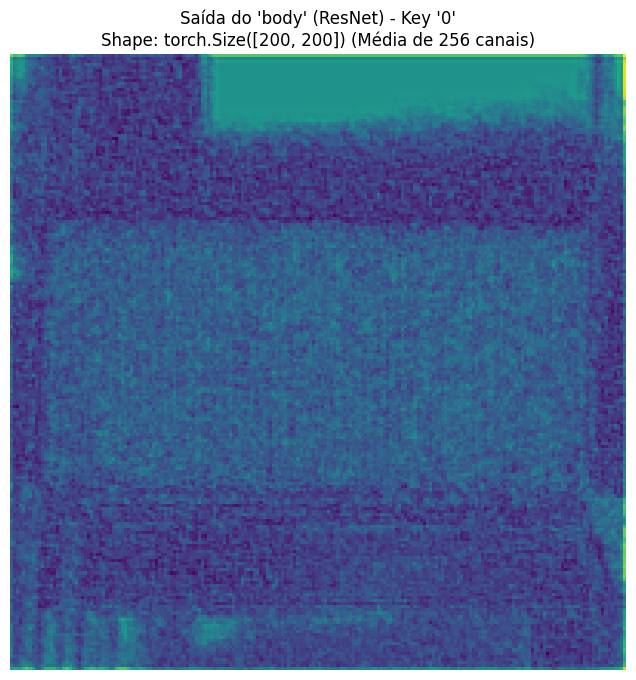

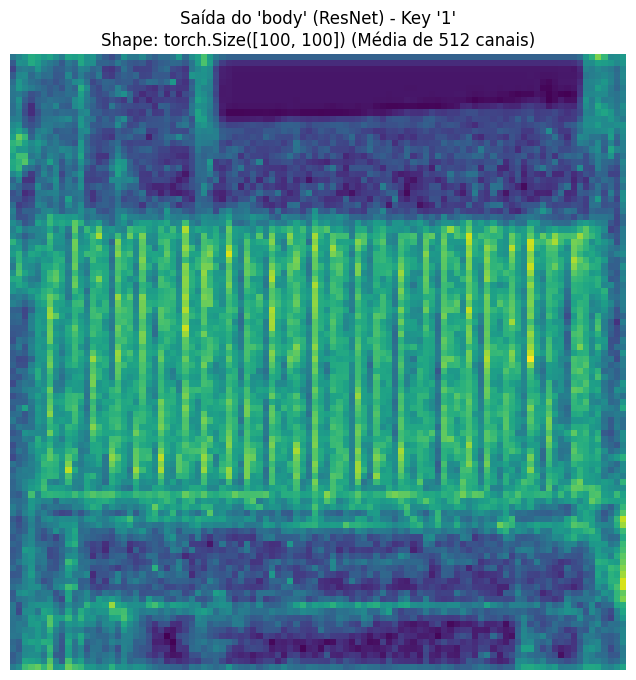

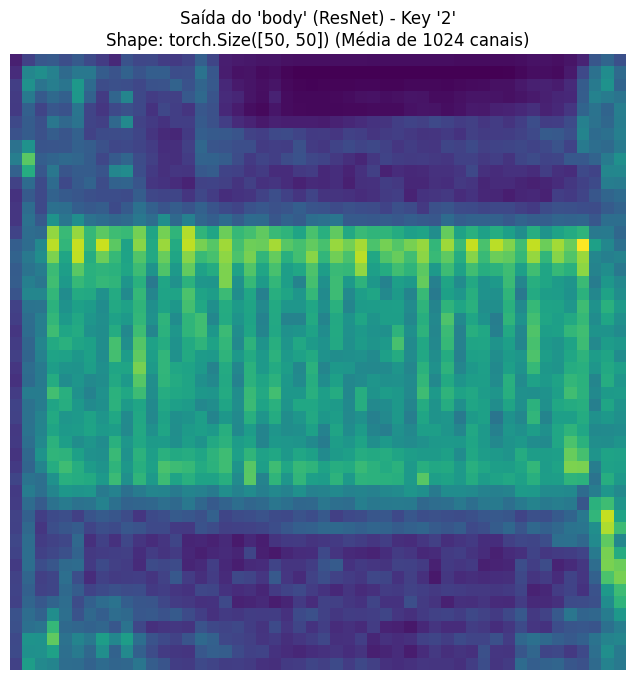

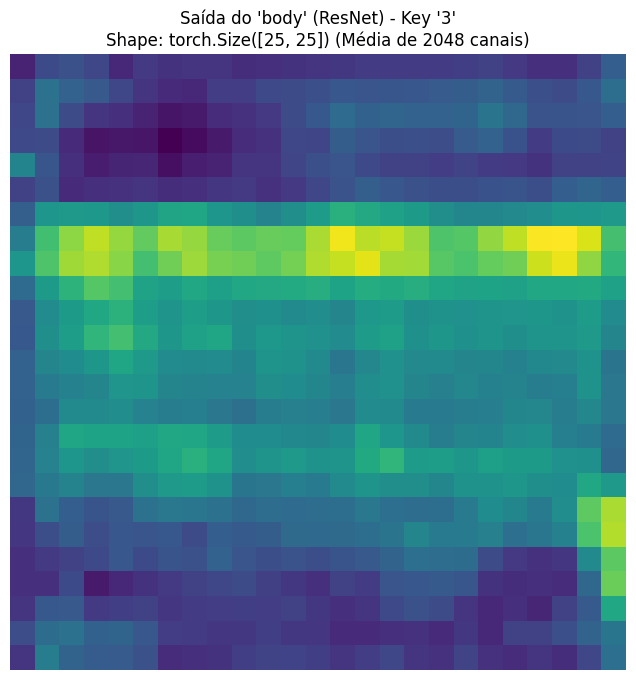

In [20]:
# --- 7. Executando o Backbone Body (ResNet-50) ---

# Esta variável armazenará a saída para ser usada na próxima etapa
body_features = None 

# Verifica se o modelo foi carregado e se a imagem foi transformada
if model and 'image_list_obj' in locals():
    print("\n\n--- Etapa 1: Executando o 'body' (ResNet-50) ---")
    
    # 'image_list_obj.tensors' é o batch de tensores 
    # pronto, vindo do model.transform (ex: [1, 3, 800, 1067])
    input_tensors = image_list_obj.tensors
    
    print(f"Input para o 'body' (shape): {input_tensors.shape}")
    
    # Desativamos o cálculo de gradientes para a inferência
    with torch.no_grad():
        
        # --- Executando model.backbone.body(input_tensors) ---
        # O 'body' (IntermediateLayerGetter) 
        # retorna um Dicionário Ordenado (OrderedDict) 
        # com as saídas das camadas de interesse.
        body_features = model.backbone.body(input_tensors)
        
        print("\nSaídas do 'body' (ResNet-50):")
        for name, tensor in body_features.items():
            print(f"  - Key: '{name}' -> Shape: {tensor.shape}")
            
        # --- Visualização do 'body' ---
        print("\nVisualizando saídas do 'body' (antes da FPN):")
        for name, tensor in body_features.items():
            show_feature_map(tensor, 
                             title=f"Saída do 'body' (ResNet) - Key '{name}'")

elif not model:
    print("\nModelo não foi carregado, impossível testar o backbone.")
else:
    print("\nExecute o passo 6 (transformação) primeiro para criar 'image_list_obj'.")

A FPN pega essas 4 saídas do body, as combina de forma inteligente (de cima para baixo e de baixo para cima) e gera um novo conjunto de mapas de características. Todos eles terão 256 canais, mas em diferentes resoluções.

As chaves que você verá ( '0', '1', '2', '3', 'pool') correspondem aos níveis da pirâmide:

Key '0' a '3': São os mapas de características P2 a P5 da pirâmide, que combinam alta resolução com características semânticas fortes. (ex: [1, 256, 200, 267], [1, 256, 100, 134], etc.).

Key 'pool': É o nível P6, usado para cobrir objetos muito grandes. É basicamente um MaxPool do último nível. (ex: [1, 256, 13, 17]).

Você verá 5 gráficos, um para cada nível da pirâmide final. São esses 5 mapas de características que são enviados para o RPN (a próxima etapa) para gerar as propostas de caixas.



--- Etapa 2: Executando a 'fpn' (Feature Pyramid Network) ---
Input para a 'fpn': Dicionário de features do 'body'
  - Key: '0' -> Shape: torch.Size([1, 256, 200, 200])
  - Key: '1' -> Shape: torch.Size([1, 512, 100, 100])
  - Key: '2' -> Shape: torch.Size([1, 1024, 50, 50])
  - Key: '3' -> Shape: torch.Size([1, 2048, 25, 25])

Saídas da 'fpn' (Pirâmide Final):
  - Key: '0' -> Shape: torch.Size([1, 256, 200, 200])
  - Key: '1' -> Shape: torch.Size([1, 256, 100, 100])
  - Key: '2' -> Shape: torch.Size([1, 256, 50, 50])
  - Key: '3' -> Shape: torch.Size([1, 256, 25, 25])
  - Key: 'pool' -> Shape: torch.Size([1, 256, 13, 13])

Visualizando saídas da 'fpn' (mapas combinados):


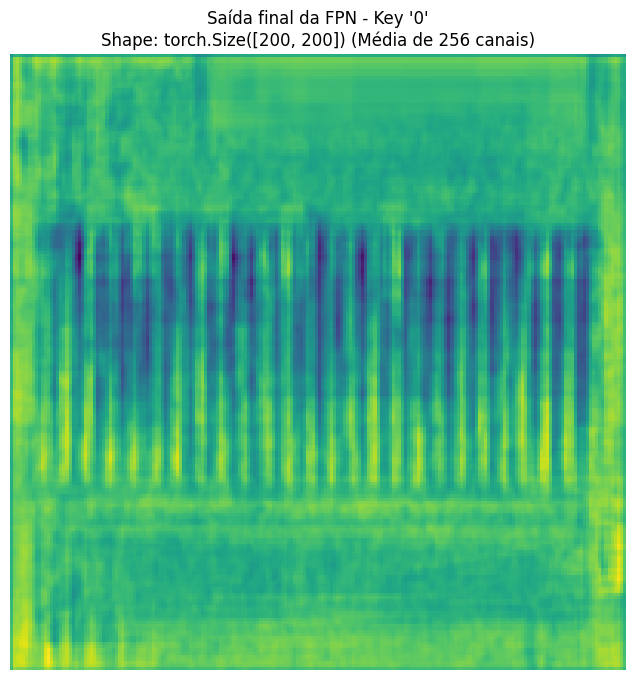

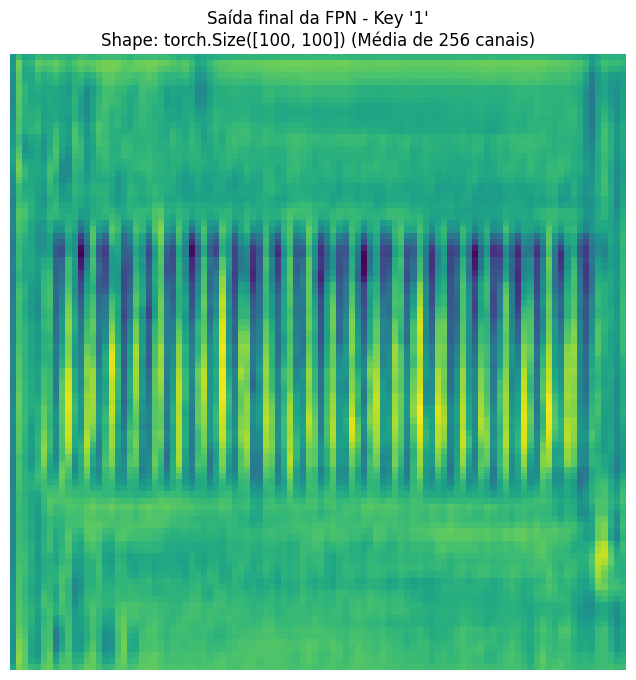

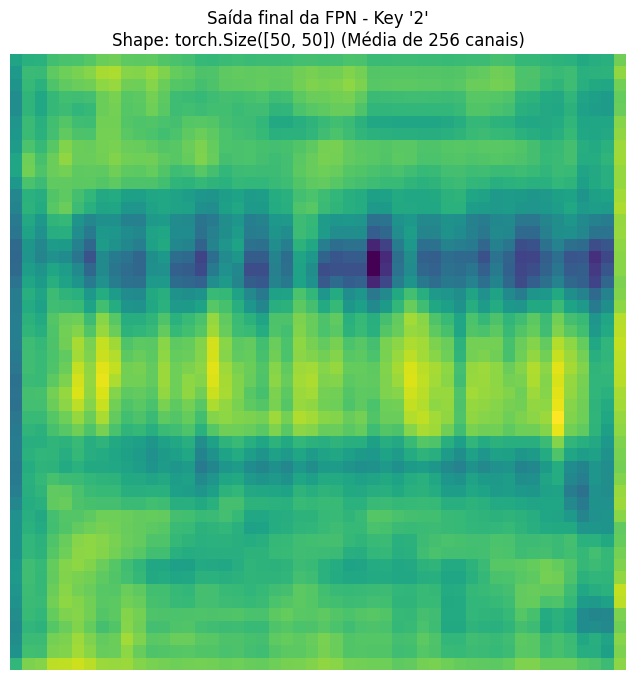

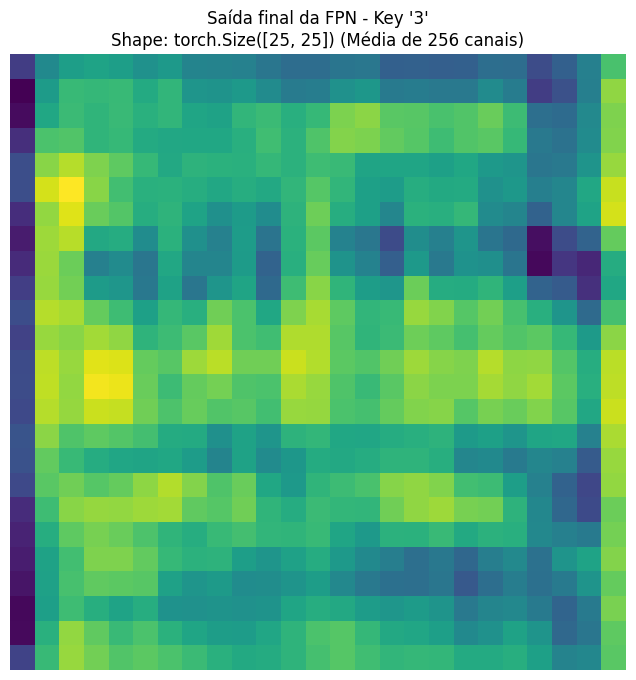

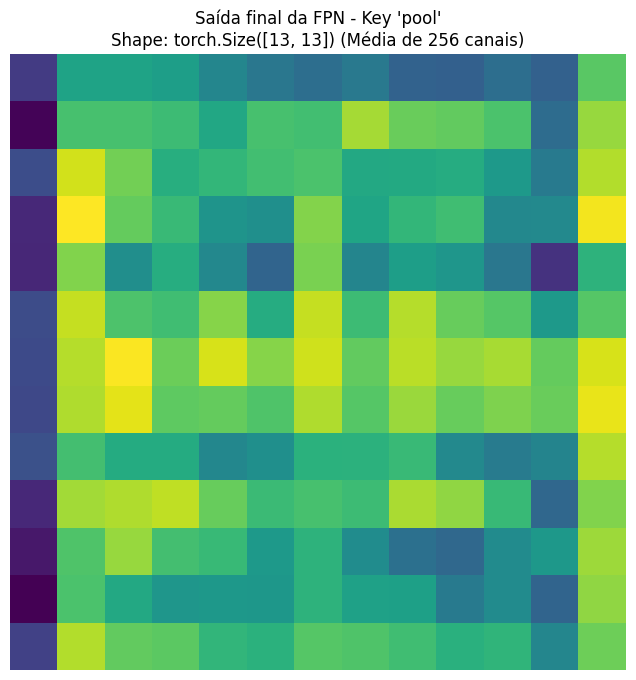


Estes são os mapas de características que seguem para o RPN.


In [22]:
# --- 8. Executando a FPN (Feature Pyramid Network) ---

# Esta variável armazenará a saída final do backbone
fpn_features = None

# Verifica se a etapa anterior ('body') foi executada com sucesso
if 'body_features' in locals() and body_features is not None:
    print("\n\n--- Etapa 2: Executando a 'fpn' (Feature Pyramid Network) ---")
    
    print("Input para a 'fpn': Dicionário de features do 'body'")
    for name, tensor in body_features.items():
            print(f"  - Key: '{name}' -> Shape: {tensor.shape}")
            
    # Desativamos o cálculo de gradientes
    with torch.no_grad():
        
        # --- Executando model.backbone.fpn(body_features) ---
        # A FPN recebe o dicionário de features do 'body'
        # e retorna um novo dicionário.
        fpn_features = model.backbone.fpn(body_features)
        
        print("\nSaídas da 'fpn' (Pirâmide Final):")
        for name, tensor in fpn_features.items():
            print(f"  - Key: '{name}' -> Shape: {tensor.shape}")

        # --- Visualização da 'fpn' ---
        print("\nVisualizando saídas da 'fpn' (mapas combinados):")
        for name, tensor in fpn_features.items():
            show_feature_map(tensor, 
                             title=f"Saída final da FPN - Key '{name}'")
                             
        print("\nEstes são os mapas de características que seguem para o RPN.")

else:
    print("\nFalha ao executar a Etapa 2 (FPN).")
    print("Certifique-se de que a Etapa 1 ('body') foi executada sem erros.")

In [26]:
from PIL import ImageDraw

def draw_boxes_on_image(pil_image, boxes_tensor, title="Imagem com Propostas", 
                          color="red", width=2, max_boxes=100):
    """
    Desenha uma lista de caixas (de um tensor) em uma imagem PIL 
    e a exibe com Matplotlib.
    
    Args:
        pil_image (PIL.Image): A imagem original.
        boxes_tensor (torch.Tensor): Tensor de shape [N, 4] 
                                     com caixas (x1, y1, x2, y2).
        max_boxes (int): Número máximo de caixas a desenhar.
    """
    # Cria uma cópia para não alterar a imagem original
    img_copy = pil_image.copy()
    draw = ImageDraw.Draw(img_copy)
    
    # Pega as primeiras 'max_boxes' do tensor
    boxes_to_draw = boxes_tensor.cpu().numpy()[:max_boxes]
    
    print(f"Desenhando as {len(boxes_to_draw)} primeiras propostas...")
    
    for box in boxes_to_draw:
        # Converte para lista de coordenadas
        box_coords = [box[0], box[1], box[2], box[3]]
        # Desenha o retângulo
        draw.rectangle(box_coords, outline=color, width=width)
        
    # Exibe a imagem
    plt.figure(figsize=(12, 12))
    plt.imshow(img_copy)
    plt.title(f"{title}\n(Mostrando {len(boxes_to_draw)} caixas)")
    plt.axis('off')
    plt.show()



--- Etapa 3: Executando a RPN (Region Proposal Network) ---
Input para a RPN: 5 mapas da FPN

--- Saída da RPN ---
Número total de propostas geradas: 1000
Shape das propostas (N, 4): torch.Size([1000, 4])

Preparando visualização das propostas...
Tamanho Imagem Original (W, H): (640, 640)
Tamanho Imagem Transformada (W, H): (800, 800)
Desenhando as 100 primeiras propostas...


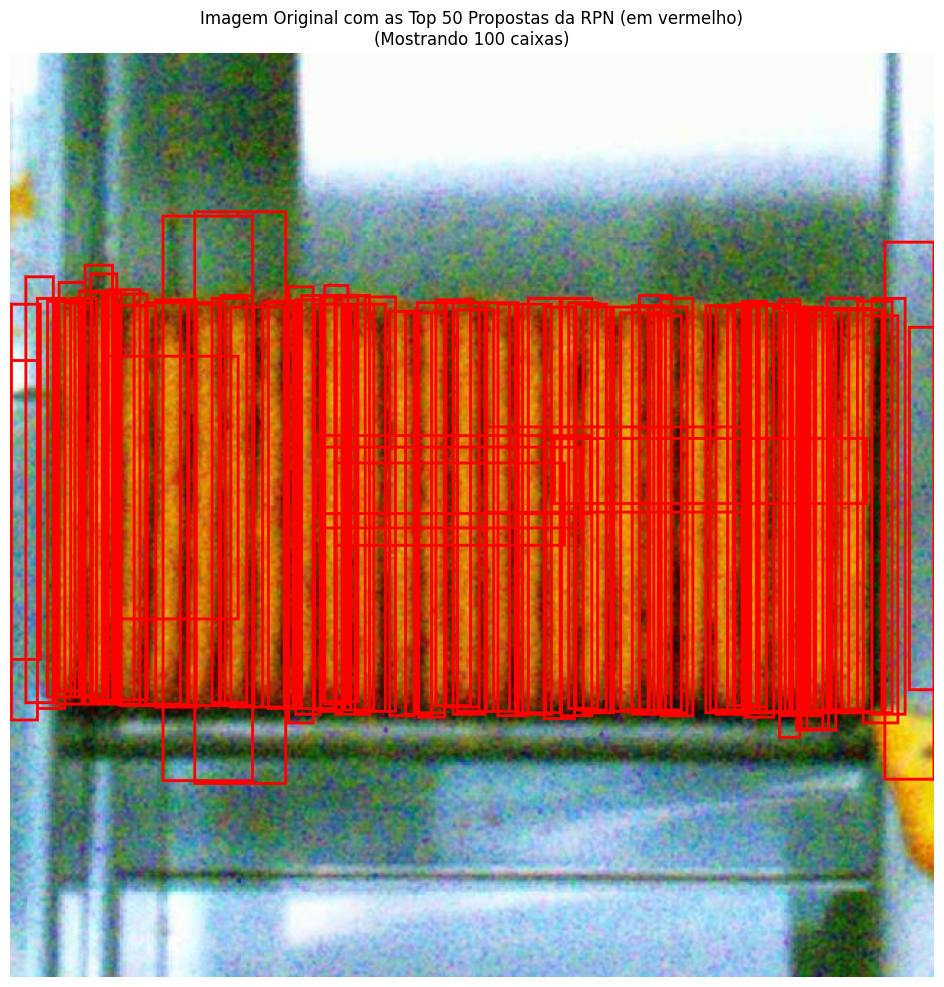

In [27]:
# --- 9. Executando a RPN (Region Proposal Network) ---

# Esta variável armazenará as propostas para a etapa final
rpn_proposals = None

# Verifica se a FPN foi executada
if 'fpn_features' in locals() and fpn_features is not None:
    print("\n\n--- Etapa 3: Executando a RPN (Region Proposal Network) ---")
    
    print(f"Input para a RPN: {len(fpn_features)} mapas da FPN")
    
    # Desativamos o cálculo de gradientes
    with torch.no_grad():
        
        # A RPN (model.rpn) precisa de duas coisas:
        # 1. O objeto 'image_list_obj' (criado pelo 'transform')
        # 2. O dicionário 'fpn_features' (criado pelo 'backbone')
        
        # Em modo .eval(), ela retorna: (proposals, proposal_losses)
        # As 'losses' (perdas) estarão vazias.
        rpn_proposals, rpn_losses = model.rpn(image_list_obj, fpn_features, None)

        print("\n--- Saída da RPN ---")
        
        # 'rpn_proposals' é uma LISTA de tensores, um por imagem no batch.
        # Como temos 1 imagem, pegamos o índice [0]
        rpn_boxes = rpn_proposals[0]
        
        print(f"Número total de propostas geradas: {rpn_boxes.shape[0]}")
        print(f"Shape das propostas (N, 4): {rpn_boxes.shape}")
        
        # --- Visualização ---
        print("\nPreparando visualização das propostas...")

        # 1. Obter tamanhos para redimensionar as caixas
        
        # Tamanho da imagem original (Largura, Altura)
        original_w, original_h = pil_image.size
        print(f"Tamanho Imagem Original (W, H): ({original_w}, {original_h})")
        
        # Tamanho da imagem transformada (Altura, Largura)
        # (Note a ordem H, W no shape do tensor)
        transformed_h, transformed_w = image_list_obj.tensors.shape[2:]
        print(f"Tamanho Imagem Transformada (W, H): ({transformed_w}, {transformed_h})")

        # 2. Calcular fatores de escala
        w_scale = original_w / transformed_w
        h_scale = original_h / transformed_h
        
        # 3. Redimensionar as caixas de volta para o tamanho original
        scaled_boxes = rpn_boxes.clone().cpu()
        scaled_boxes[:, 0] *= w_scale # x1
        scaled_boxes[:, 1] *= h_scale # y1
        scaled_boxes[:, 2] *= w_scale # x2
        scaled_boxes[:, 3] *= h_scale # y3

        # 4. Chamar a função para desenhar as caixas
        # (Usamos a 'pil_image' original que carregamos no passo 6)
        draw_boxes_on_image(
            pil_image, 
            scaled_boxes, 
            title="Imagem Original com as Top 50 Propostas da RPN (em vermelho)"
        )

else:
    print("\nFalha ao executar a Etapa 3 (RPN).")
    print("Certifique-se de que a Etapa 2 (FPN) foi executada sem erros.")

In [28]:
from PIL import ImageDraw, ImageFont

def draw_final_detections(pil_image, detections_dict, class_names, 
                            threshold=0.5, color_map=None):
    """
    Desenha as detecções finais (caixas, rótulos, pontuações) em uma imagem PIL.
    Filtra detecções abaixo do 'threshold'.
    
    Args:
        pil_image (PIL.Image): A imagem original.
        detections_dict (dict): Dicionário com 'boxes', 'labels', 'scores'.
        class_names (dict): Mapeamento de ID de label (int) para nome (str).
        threshold (float): Limite de confiança para exibir uma detecção.
    """
    # Cores padrão para as classes (você pode estender isso)
    if color_map is None:
        color_map = {
            1: 'green', 2: 'blue', 3: 'orange', 4: 'purple',
            5: 'red', 6: 'yellow', 7: 'cyan'
        }
        
    # Tenta carregar uma fonte; se falhar, não desenha o texto
    try:
        # Você pode precisar mudar "arial.ttf" para uma fonte válida 
        # no seu sistema (ex: "calibri.ttf" no Windows)
        font = ImageFont.truetype("arial.ttf", 15)
    except IOError:
        print("Aviso: Fonte 'arial.ttf' não encontrada. Desenhando sem texto.")
        font = None
        
    img_copy = pil_image.copy()
    draw = ImageDraw.Draw(img_copy)
    
    boxes = detections_dict['boxes']
    labels = detections_dict['labels']
    scores = detections_dict['scores']
    
    detections_drawn = 0
    
    for i in range(len(scores)):
        score = scores[i]
        label = labels[i]
        
        # 1. Filtra pela pontuação (threshold) e pelo rótulo (não desenha 'Fundo')
        if score > threshold and label != 0:
            detections_drawn += 1
            
            # 2. Pega as coordenadas e a cor
            box = boxes[i].tolist() # [x1, y1, x2, y2]
            
            # Pega a cor; usa 'white' como padrão se a classe não estiver no mapa
            default_color = 'white'
            color = color_map.get(label, default_color)
            
            # 3. Desenha a caixa
            draw.rectangle(box, outline=color, width=3)
            
            # 4. Prepara o texto
            class_name = class_names.get(label, f"Label {label}")
            text = f"{class_name}: {score:.2f}"
            
            # 5. Desenha o texto (se a fonte foi carregada)
            if font:
                # Desenha um fundo para o texto
                text_bbox = draw.textbbox((box[0], box[1] - 15), text, font=font)
                draw.rectangle(text_bbox, fill=color)
                draw.text((box[0], box[1] - 15), text, fill="black", font=font)

    # Exibe a imagem final
    plt.figure(figsize=(12, 12))
    plt.imshow(img_copy)
    plt.title(f"Detecções Finais (Confiança > {threshold})\n{detections_drawn} objetos encontrados")
    plt.axis('off')
    plt.show()



--- Etapa 4: Executando as RoI Heads (Etapa Final) ---
Input 1: 5 mapas da FPN
Input 2: 1000 propostas da RPN

--- Saída das RoI_Heads (Detecções Finais) ---
Total de caixas finais: 26
Shape dos scores: torch.Size([26])
Shape dos labels: torch.Size([26])

Preparando visualização das detecções finais...


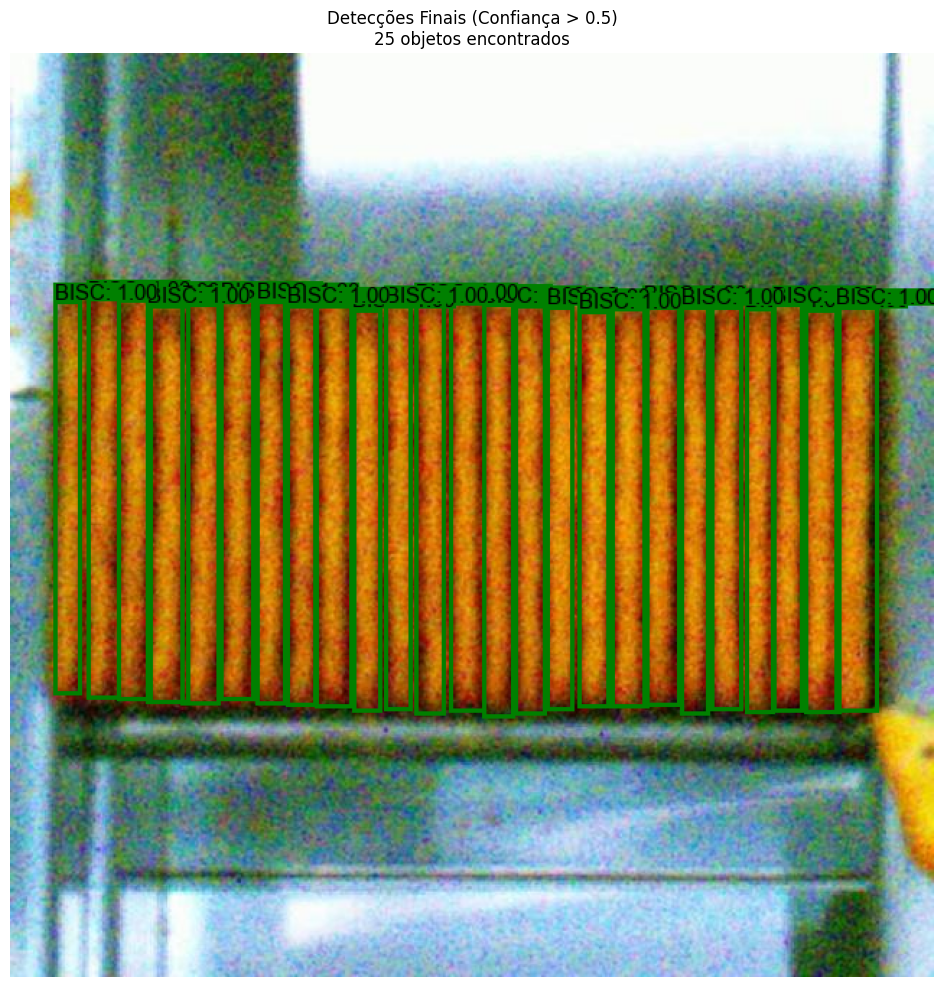

In [30]:
# --- 10. Executando as RoI Heads (Classificação Final) ---

# Verifica se as etapas anteriores foram executadas
if ('fpn_features' in locals() and fpn_features is not None) and \
   ('rpn_proposals' in locals() and rpn_proposals is not None):
    
    print("\n\n--- Etapa 4: Executando as RoI Heads (Etapa Final) ---")
    
    print(f"Input 1: {len(fpn_features)} mapas da FPN")
    print(f"Input 2: {len(rpn_proposals[0])} propostas da RPN")
    
    # Desativamos o cálculo de gradientes
    with torch.no_grad():
        
        # As 'RoI Heads' precisam dos mapas, das propostas e
        # dos tamanhos das imagens (para 'clipar' as caixas)
        image_sizes = image_list_obj.image_sizes
        
        # Em modo .eval(), retorna: (detections, detector_losses)
        # As 'losses' (perdas) estarão vazias.
        detections, detector_losses = model.roi_heads(
            fpn_features, 
            rpn_proposals, 
            image_sizes, 
            None  # 'None' para os alvos (targets) em modo de avaliação
        )

        print("\n--- Saída das RoI_Heads (Detecções Finais) ---")
        
        # 'detections' é uma LISTA de dicionários, um por imagem no batch.
        # Pegamos o primeiro (e único) item, [0]
        final_detections = detections[0]
        
        print(f"Total de caixas finais: {final_detections['boxes'].shape[0]}")
        print(f"Shape dos scores: {final_detections['scores'].shape}")
        print(f"Shape dos labels: {final_detections['labels'].shape}")

        # --- Visualização Final ---
        print("\nPreparando visualização das detecções finais...")

        # 1. Obter tamanhos para redimensionar as caixas (igual à etapa da RPN)
        original_w, original_h = pil_image.size
        transformed_h, transformed_w = image_list_obj.tensors.shape[2:]
        w_scale = original_w / transformed_w
        h_scale = original_h / transformed_h
        
        # 2. Redimensionar as caixas de volta para o tamanho original
        scaled_boxes = final_detections['boxes'].clone().cpu()
        scaled_boxes[:, 0] *= w_scale # x1
        scaled_boxes[:, 1] *= h_scale # y1
        scaled_boxes[:, 2] *= w_scale # x2
        scaled_boxes[:, 3] *= h_scale # y3

        # 3. Criar um novo dicionário com os dados no formato correto (CPU)
        scaled_detections = {
            'boxes': scaled_boxes,
            'labels': final_detections['labels'].cpu().numpy(),
            'scores': final_detections['scores'].cpu().numpy()
        }

        # 4. !!! DEFINA SUAS CLASSES E O LIMITE DE CONFIANÇA !!!
        # Seu modelo foi treinado com 'num_classes = 2'.
        # Isso significa: 0 = Fundo, 1 = Sua Classe.
        CLASS_NAMES = {
            0: 'Fundo',
            1: 'BISC' # <-- MUDE ISSO
            # Se tivesse mais classes: 2: 'Classe 2', 3: 'Classe 3'
        }
        
        # Defina o limite de confiança (só mostra caixas com pontuação > 0.5)
        CONFIDENCE_THRESHOLD = 0.5
        
        # 5. Chamar a função para desenhar as detecções finais
        draw_final_detections(
            pil_image, 
            scaled_detections, 
            CLASS_NAMES, 
            threshold=CONFIDENCE_THRESHOLD
        )

else:
    print("\nFalha ao executar a Etapa 4 (RoI Heads).")